<a href="https://colab.research.google.com/github/mateus-ferreira-gomes/python-fundamentals/blob/main/modelos_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍷 Classificação de Qualidade de Vinhos com Regressão Logística

Este notebook aplica técnicas de Machine Learning para classificar vinhos com base em suas características químicas.

## 📋 Roteiro do Projeto:
1. **Setup**: Importação de bibliotecas
2. **Dados**: Carregamento e Exploração inicial
3. **Preparação**: Limpeza e divisão (Treino/Teste)
4. **Baseline**: Treinamento do modelo inicial
5. **Otimização**: Pipeline + GridSearchCV
6. **Avaliação**: Métricas estatísticas e Matriz de Confusão

# 🛠️ 1. Configuração e Importação
Carregamos as ferramentas necessárias para manipulação de dados, modelagem e visualização.

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Para visualização no notebook
%matplotlib inline

# Regressão Logística

Apesar do nome, a regressão logística é usada para **classificação**.



In [122]:
# Importando modelo de Regressão Logística

from sklearn.linear_model import LogisticRegression  # modelo de classificação


In [123]:
# Conectando ao Google Drive para acessar o arquivo CSV
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [124]:
# Carregamento
df = pd.read_csv('/content/drive/MyDrive/df_processado.csv')

# Padronização de colunas
df.columns = ['Unnamed: 0', 'acidez fixa', 'acidez volátil', 'ácido cítrico', 'açúcar residual', 'cloretos', 'dióxido de enxofre livre', 'dióxido de enxofre total', 'densidade', 'pH', 'sulfatos', 'álcool', 'qualidade', 'target']

# Visualização rápida
display(df.head())
df.info()

,Unnamed: 0,acidez fixa,acidez volátil,ácido cítrico,açúcar residual,cloretos,dióxido de enxofre livre,dióxido de enxofre total,densidade,pH,sulfatos,álcool,qualidade,target
0,0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                6497 non-null   int64  
 1   acidez fixa               6497 non-null   float64
 2   acidez volátil            6497 non-null   float64
 3   ácido cítrico             6497 non-null   float64
 4   açúcar residual           6497 non-null   float64
 5   cloretos                  6497 non-null   float64
 6   dióxido de enxofre livre  6497 non-null   float64
 7   dióxido de enxofre total  6497 non-null   float64
 8   densidade                 6497 non-null   float64
 9   pH                        6497 non-null   float64
 10  sulfatos                  6497 non-null   float64
 11  álcool                    6497 non-null   float64
 12  qualidade                 6497 non-null   int64  
 13  target                    6497 non-null   object 
dtypes: float

In [125]:
df.columns

Index(['Unnamed: 0', 'acidez fixa', 'acidez volátil', 'ácido cítrico',
       'açúcar residual', 'cloretos', 'dióxido de enxofre livre',
       'dióxido de enxofre total', 'densidade', 'pH', 'sulfatos', 'álcool',
       'qualidade', 'target'],
      dtype='object')

In [126]:
# Renomeando colunas (mantendo padrão do dataset de vinho)

df.columns = ['Unnamed: 0', 'acidez fixa', 'acidez volátil', 'ácido cítrico',
       'açúcar residual', 'cloretos', 'dióxido de enxofre livre',
       'dióxido de enxofre total', 'densidade', 'pH', 'sulfatos', 'álcool',
       'qualidade', 'target']

# Visualizar novamente
df.head()

,Unnamed: 0,acidez fixa,acidez volátil,ácido cítrico,açúcar residual,cloretos,dióxido de enxofre livre,dióxido de enxofre total,densidade,pH,sulfatos,álcool,qualidade,target
0,0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


# Estatísticas do dataset


In [127]:
df.describe()  # resumo estatístico


,Unnamed: 0,acidez fixa,acidez volátil,ácido cítrico,açúcar residual,cloretos,dióxido de enxofre livre,dióxido de enxofre total,densidade,pH,sulfatos,álcool,qualidade
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,3248.000000,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1875.666681,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,0.000000,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,1624.000000,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,3248.000000,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,4872.000000,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,6496.000000,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [128]:
df.info()  # informações gerais

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                6497 non-null   int64  
 1   acidez fixa               6497 non-null   float64
 2   acidez volátil            6497 non-null   float64
 3   ácido cítrico             6497 non-null   float64
 4   açúcar residual           6497 non-null   float64
 5   cloretos                  6497 non-null   float64
 6   dióxido de enxofre livre  6497 non-null   float64
 7   dióxido de enxofre total  6497 non-null   float64
 8   densidade                 6497 non-null   float64
 9   pH                        6497 non-null   float64
 10  sulfatos                  6497 non-null   float64
 11  álcool                    6497 non-null   float64
 12  qualidade                 6497 non-null   int64  
 13  target                    6497 non-null   object 
dtypes: float

### Explicação das colunas

- acidez fixa -> ácidos que não evaporam
- acidez volátil -> influencia no cheiro
- ácido cítrico -> contribui para sabor
- açúcar residual -> açúcar restante após fermentação
- cloretos -> nível de sal
- dióxido de enxofre -> conservante
- densidade -> relação massa/volume
- pH -> acidez
- sulfatos -> preservação
- álcool -> teor alcoólico
- qualidade -> nota do vinho
- target -> classificação (bom = 1, ruim = 0)

In [129]:
# 1. Divisão Inicial: Separando o Teste (Etapa Final e Intocável)
# Reservamos 15% dos dados que o modelo NUNCA verá durante o treinamento ou ajuste
features_treino, features_teste, target_treino, target_teste = train_test_split(
    features, target, test_size=0.15, random_state=42, stratify=target
)

print(f"Dados de Treino (para CV): {features_treino.shape[0]}")
print(f"Dados de Teste (Final): {features_teste.shape[0]}")

Dados de Treino (para CV): 5522
Dados de Teste (Final): 975


## 📊 Avaliação Estatística Detalhada

Além da acurácia simples, vamos analisar a precisão do modelo para cada classe usando uma Matriz de Confusão e o Classification Report.

Acurácia Global do Modelo: 99.49%

Relatório de Classificação:
              precision    recall  f1-score   support

         red       0.99      0.99      0.99       240
       white       1.00      1.00      1.00       735

    accuracy                           0.99       975
   macro avg       0.99      0.99      0.99       975
weighted avg       0.99      0.99      0.99       975

--- Explicação da Matriz ---
Vinhos red detectados corretamente: 238
Vinhos white detectados corretamente: 732
Erros: red confundidos com white: 2
Erros: white confundidos com red: 3


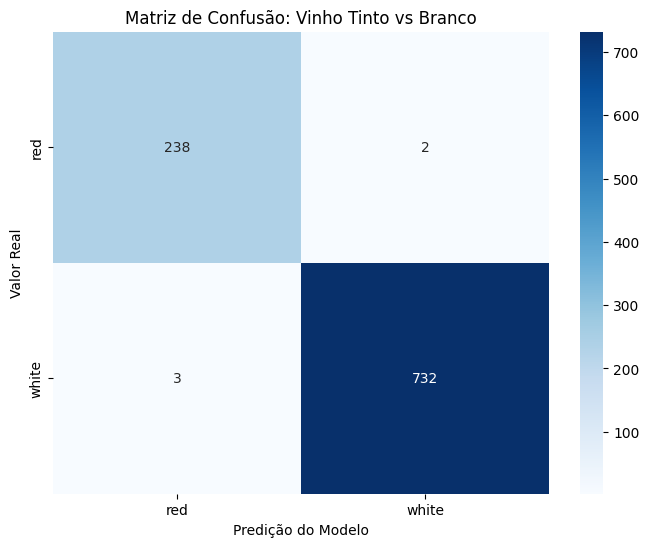

In [130]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Garantindo que as predições correspondam ao conjunto de teste atual
pred_final = melhor_modelo.predict(features_teste)

# Acurácia Global
accuracy = accuracy_score(target_teste, pred_final)
print(f'Acurácia Global do Modelo: {accuracy:.2%}\n')

# Relatório Detalhado
print('Relatório de Classificação:')
print(classification_report(target_teste, pred_final))

# Matriz de Confusão
cm = confusion_matrix(target_teste, pred_final)

# Extração de valores da matriz
tn, fp, fn, tp = cm.ravel()

print('--- Explicação da Matriz ---')
print(f'Vinhos {melhor_modelo.classes_[0]} detectados corretamente: {tn}')
print(f'Vinhos {melhor_modelo.classes_[1]} detectados corretamente: {tp}')
print(f'Erros: {melhor_modelo.classes_[0]} confundidos com {melhor_modelo.classes_[1]}: {fp}')
print(f'Erros: {melhor_modelo.classes_[1]} confundidos com {melhor_modelo.classes_[0]}: {fn}')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=melhor_modelo.classes_,
            yticklabels=melhor_modelo.classes_)
plt.title('Matriz de Confusão: Vinho Tinto vs Branco')
plt.ylabel('Valor Real')
plt.xlabel('Predição do Modelo')
plt.show()

# 📂 2. Carregamento e Exploração de Dados
Conectamos ao Google Drive e analisamos a estrutura básica do dataset.

# ⚙️ 3. Engenharia de Atributos e Preparação
Separação das variáveis explicativas (X) e do alvo (y), seguida da divisão para validação.

# 🧠 4. Criação e Treinamento do Modelo (Baseline)

Nesta etapa, criamos o 'cérebro' do nosso projeto.

Utilizamos um modelo de **Regressão Logística**. Apesar do nome sugerir 'regressão', ele é um dos algoritmos mais eficientes para **classificação** (decidir entre duas categorias: Tinto ou Branco).

# 📊 6. Avaliação Final de Performance
Análise profunda dos resultados do melhor modelo encontrado.

In [131]:
# ✂️ Divisão: Separando 90% para treinar o 'cérebro' do modelo e 10% para testar o acerto
features_treino, features_teste, target_treino, target_teste = train_test_split(
    features, target, test_size=0.10, random_state=42
)

In [132]:
# Criando o modelo

modelo = LogisticRegression(max_iter=1000)  # evita erro de convergência



In [133]:
# Treinamento inicial
modelo_simples = LogisticRegression(max_iter=1000)
modelo_simples.fit(features_treino, target_treino)

# Predição inicial
pred_simples = modelo_simples.predict(features_teste)
print(f'Acurácia Inicial: {accuracy_score(target_teste, pred_simples):.2%}')

Acurácia Inicial: 97.69%


In [134]:
# 🔍 Testando o modelo na prática
# Vamos pedir para o modelo prever o tipo de 5 vinhos que ele nunca viu antes

pred = modelo_simples.predict(features_teste)

print("--- Comparação: Real vs Predito ---")
for i in range(5):
    real = target_teste.iloc[i]
    previsto = pred[i]
    status = "✅ Acertou!" if real == previsto else "❌ Errou"
    print(f"Vinho {i+1}: Real = {real} | Predito = {previsto} -> {status}")

--- Comparação: Real vs Predito ---
Vinho 1: Real = white | Predito = white -> ✅ Acertou!
Vinho 2: Real = red | Predito = white -> ❌ Errou
Vinho 3: Real = white | Predito = white -> ✅ Acertou!
Vinho 4: Real = white | Predito = white -> ✅ Acertou!
Vinho 5: Real = white | Predito = white -> ✅ Acertou!


In [135]:
# ✅ Avaliação Final
accuracy = accuracy_score(target_teste, pred)
print(f'Acurácia Global do Modelo: {accuracy:.2%}')

Acurácia Global do Modelo: 97.69%


### Entendendo o resultado

A acurácia mostra quantos vinhos foram classificados corretamente.

Exemplo:
Se a acurácia for 0.85 → significa 85% de acerto.

Mas cuidado: a acurácia pode enganar dependendo da distribuição dos dados.

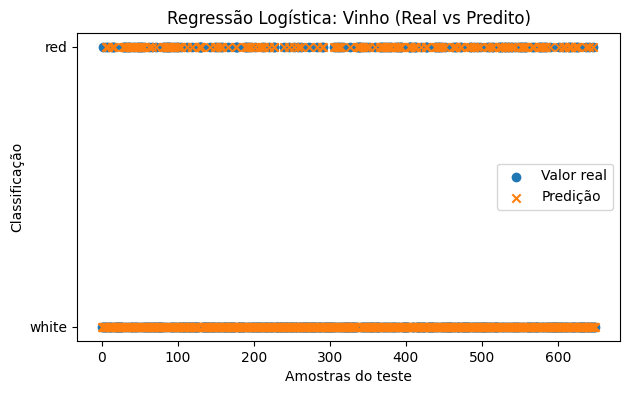

In [136]:
# Comparando valores reais vs previstos

plt.figure(figsize=(7,4))

# valores reais
plt.scatter(range(len(target_teste)), target_teste,
            marker="o", label="Valor real")

# valores previstos
plt.scatter(range(len(pred)), pred,
            marker="x", label="Predição")

plt.xlabel("Amostras do teste")
plt.ylabel("Classificação")
plt.title("Regressão Logística: Vinho (Real vs Predito)")

plt.legend()
plt.show()

# 🚀 5. Otimização Avançada: Pipeline + GridSearchCV

Agora que temos um modelo básico, vamos tentar extrair a **máxima performance**.

### O que estamos fazendo aqui?
1. **StandardScaler**: Colocamos todos os dados químicos na mesma escala (como se estivéssemos normalizando pesos e alturas).
2. **GridSearchCV**: Testamos automaticamente várias 'receitas' (parâmetros) para ver qual delas faz o modelo ser mais certeiro.
3. **StratifiedKFold**: Garantimos que o modelo seja testado em várias partes diferentes dos dados para evitar que ele apenas 'decore' o padrão.

In [137]:
# 2. Tunagem de Hiperparâmetros com Cross-Validation (Dados de Treino)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

param_grid = {
    'logreg__C': [0.1, 1, 10, 100],
    'logreg__solver': ['lbfgs', 'liblinear']
}

# O StratifiedKFold garante que cada 'dobra' da validação cruzada respeite a proporção das classes
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# O GridSearch divide internamente o 'features_treino' em Treino e Validação
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(features_treino, target_treino)

print(f'Melhores Parâmetros encontrados no CV: {grid.best_params_}')
print(f'Melhor Acurácia de Validação: {grid.best_score_:.2%}')

Melhores Parâmetros encontrados no CV: {'logreg__C': 1, 'logreg__solver': 'liblinear'}
Melhor Acurácia de Validação: 99.44%


# 🏁 6. Avaliação do Melhor Modelo Retreinado
O GridSearchCV automaticamente retreina o melhor modelo com todos os dados de treino.

### 🔍 Análise Detalhada dos Testes (GridSearchCV)
Abaixo, listamos as 5 melhores combinações de parâmetros testadas durante a validação cruzada.

In [138]:
import pandas as pd

# Transformando os resultados da busca em um DataFrame
resultados = pd.DataFrame(grid.cv_results_)

# Selecionando e ordenando as colunas mais importantes
colunas_interesse = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
ranking_modelos = resultados[colunas_interesse].sort_values(by='rank_test_score')

# Exibindo os 5 melhores
display(ranking_modelos.head())

,params,mean_test_score,std_test_score,rank_test_score
3,"{'logreg__C': 1, 'logreg__solver': 'liblinear'}",0.994356,0.001676,1
6,"{'logreg__C': 100, 'logreg__solver': 'lbfgs'}",0.994185,0.001906,2
5,"{'logreg__C': 10, 'logreg__solver': 'liblinear'}",0.994185,0.001906,2
4,"{'logreg__C': 10, 'logreg__solver': 'lbfgs'}",0.994185,0.001906,2
7,"{'logreg__C': 100, 'logreg__solver': 'liblinear'}",0.994185,0.001906,2


--- PERFORMANCE FINAL NO TESTE (DADOS NÃO VISTOS) ---
              precision    recall  f1-score   support

         red       0.97      1.00      0.99       172
       white       1.00      0.99      0.99       478

    accuracy                           0.99       650
   macro avg       0.99      0.99      0.99       650
weighted avg       0.99      0.99      0.99       650



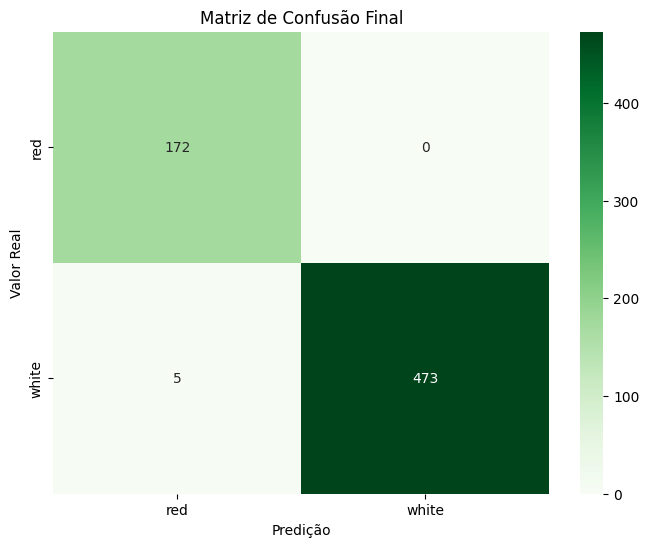

In [139]:
# 3. Avaliação de Performance na Etapa Final (Dados de Teste)
# Agora sim, usamos o conjunto de teste que estava guardado
melhor_modelo = grid.best_estimator_
pred_final = melhor_modelo.predict(features_teste)

print('--- PERFORMANCE FINAL NO TESTE (DADOS NÃO VISTOS) ---')
print(classification_report(target_teste, pred_final))

# Matriz de Confusão para validar erros e acertos
cm = confusion_matrix(target_teste, pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=melhor_modelo.classes_,
            yticklabels=melhor_modelo.classes_)
plt.title('Matriz de Confusão Final')
plt.ylabel('Valor Real')
plt.xlabel('Predição')
plt.show()

### 💡 Entendendo a Lógica do Modelo

A regressão logística calcula a **probabilidade** de um vinho pertencer a uma classe.

Imagine que o modelo analisa a acidez e o álcool e pensa:
> *"Tem 98% de chance de ser um vinho Branco e 2% de chance de ser Tinto."*

Como 98% é maior que 50%, ele carimba o rótulo como **Branco**.

### Explicando o Resultado

A regressão logística calcula a probabilidade de algo pertencer a uma classe.

Se a probabilidade passar de 50%, o modelo escolhe aquela classe.

Imagine um médico analisando um tumor.
Ele não pensa "é benigno ou maligno" imediatamente.

Ele pensa algo como:

*“Parece benigno com 80% de chance.”*

A regressão faz exatamente isso, mas usando matemática.